In [ ]:
!pip install swig
!pip install box2d
!pip install "gymnasium[all]"

In [ ]:
import gymnasium as gym
import numpy as np
from collections import defaultdict
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator

In [ ]:
def make_graph(q):
    p_s = [i for i in range(12,22)]
    d_s = [i for i in range(1,11)]

    ace = list()
    no_ace = list()
    for i in p_s:
        for j in d_s:
            aux = list()
            aux2 = list()
            for k in range(0,2):
                a = q[((i,j,True),k)]
                if a != float("-inf"):
                    aux.append(a)
                b = q[((i,j,False),k)]
                if b != float("-inf"):
                    aux2.append(b)
            ace.append(np.array(aux).mean())
            no_ace.append(np.array(aux2).mean())

    X,Y = np.meshgrid(d_s,p_s)
    Z1 = np.array(ace).reshape(10,10)
    Z1 = np.nan_to_num(Z1)
    Z2 = np.array(no_ace).reshape(10,10)
    Z2 = np.nan_to_num(Z2)

    fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
    surf = ax.plot_surface(X, Y, Z1, cmap=cm.coolwarm, linewidth=0, antialiased=False)
    plt.show()

    fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
    surf = ax.plot_surface(X, Y, Z2, cmap=cm.coolwarm, linewidth=0, antialiased=False)
    plt.show()

In [ ]:
def act_space():
    return [0,1]

In [ ]:
def arg_max(q, s):
    max_r = float("-inf")
    max_a = -1
    for a in act_space():
        s_a = (s, a)
        r = q[s_a]
        if r > max_r:
            max_r = r
            max_a = a
    return max_a

In [ ]:
def get_action(pi, obs):
    cumul_prov = 0
    act_dist = dict()
    for a in act_space():
        prov = pi[(obs, a)]
        cumul_prov += prov
        act_dist[cumul_prov] = a
    r = np.random.random()
    for p in act_dist:
        if r < p:
            return act_dist[p]

In [ ]:
def update_pi(pi, s, a_star, epsilon):
    for a in act_space():
        s_a = (s, a)
        if a == a_star:
            pi[s_a] = (1 - epsilon) + (epsilon/2)
        else:
            pi[s_a] = epsilon/2

In [ ]:
def make_episode(env, pi):
    episode = list()
    obs, _ = env.reset()
    term = False
    while term == False:
        step = dict()
        action = get_action(pi,obs)
        obs, reward, term, trun, info = env.step(action)
        step['s'] = obs
        step['a'] = action
        step['r'] = reward
        episode.append(step)
    return episode

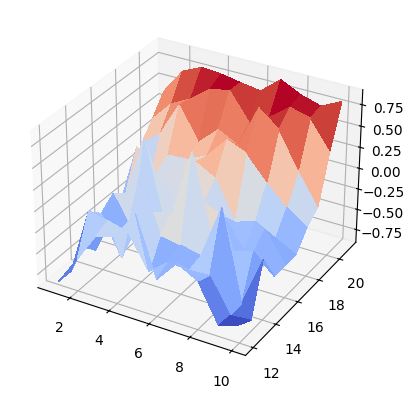

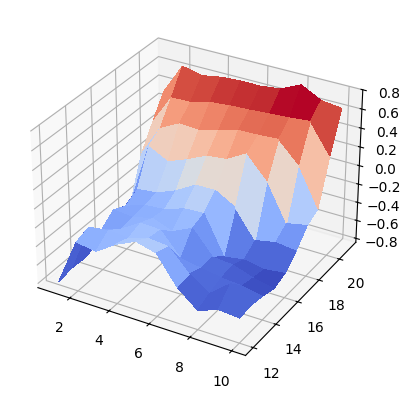

In [17]:
env = gym.make('Blackjack-v1', natural=False, sab=False)
pi = defaultdict(lambda : 1/len(act_space()))
q = defaultdict(lambda : float("-inf"))
returns = defaultdict(list)
number_of_episodes = 50000
gamma = 1
epsilon = 0.5

for e in range(number_of_episodes):
    episode = make_episode(env, pi)

    g = 0
    visited = set()

    # Loop backward through the steps of the episode
    for step in reversed(episode):
        g = gamma * g + step['r']
        s_a = (step['s'], step['a'])

        # First-Visit Check
        if s_a not in visited:
            visited.add(s_a)
            returns[s_a].append(g)
            q[s_a] = np.mean(returns[s_a])
            max_a = arg_max(q, step['s'])
            update_pi(pi, step['s'], max_a, epsilon)

make_graph(q)
env.close()


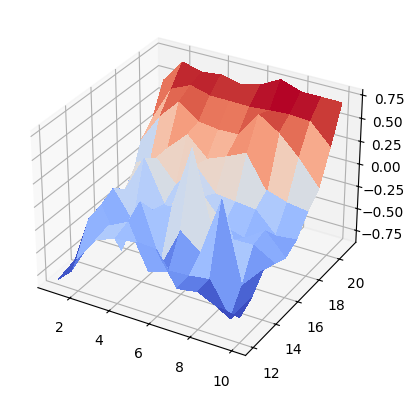

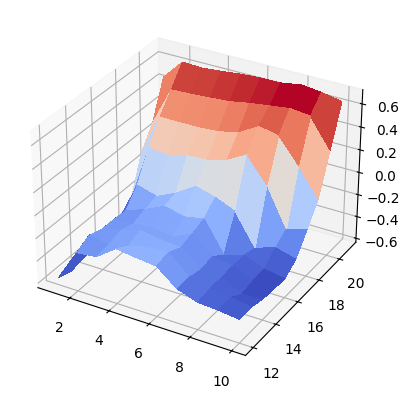

In [20]:
total = 90_000
epsilon = 0.1
gamma = 1

for i in range(total):
    episode = make_episode(env,pi)
    g = 0
    visited = set()

    # Loop backward through the episode steps
    for i in reversed(range(len(episode))):
        step = episode[i]
        reward = step['r']
        action = step['a']
        state = step['s']

        # Accumulate the return (g)
        g = gamma * g + reward

        s_a = (state, action)
        if not s_a in visited:
            visited.add(s_a)
            # Append 'g' (total return)
            returns[s_a].append(g)
            q[s_a] = np.average(returns[s_a])
            a_star = arg_max(q, state)
            update_pi(pi, state, a_star,epsilon)

make_graph(q)
env.close()


In [21]:
def make_greedy_episode(env, q):
    """Plays one episode using ONLY the learned Q-values — no more exploration.
    This measures how good the policy actually is, not how it behaved while
    still exploring during training."""
    episode = list()
    obs, _ = env.reset()
    term = False
    while term == False:
        step = dict()
        action = arg_max(q, obs)
        if action == -1:
            # State was never visited during training, fall back to "stick" (0)
            action = 0
        obs, reward, term, trun, info = env.step(action)
        step['s'] = obs
        step['a'] = action
        step['r'] = reward
        episode.append(step)
    return episode

eval_env = gym.make('Blackjack-v1', natural=False, sab=False)
n_eval_episodes = 10_000

wins = losses = draws = 0

for _ in range(n_eval_episodes):
    episode = make_greedy_episode(eval_env, q)
    outcome = episode[-1]['r']  # terminal reward: +1 win, -1 loss, 0 push
    if outcome > 0:
        wins += 1
    elif outcome < 0:
        losses += 1
    else:
        draws += 1

eval_env.close()

print(f"Evaluated over {n_eval_episodes} episodes using the greedy policy:")
print(f"  Win rate:  {wins/n_eval_episodes*100:.2f}%")
print(f"  Loss rate: {losses/n_eval_episodes*100:.2f}%")
print(f"  Push rate: {draws/n_eval_episodes*100:.2f}%")

Evaluated over 10000 episodes using the greedy (learned) policy:
  Win rate:  39.79%
  Loss rate: 51.62%
  Push rate: 8.59%
